In [8]:
import os
import csv
import geopandas as gpd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from shapely.geometry import Point
import rasterio
from rasterio.plot import show
from rasterio.crs import CRS
from rasterio.warp import calculate_default_transform, reproject, Resampling
from rasterio import mask
from shapely.geometry import mapping
import json
from shapely.geometry import shape
from rasterio.io import MemoryFile
from shapely.geometry import box

# PIXCVec polygon nodes summary bins for manually digitized water masks

Inputs

In [85]:
# set project CRS (EPSG:4326 (world) or EPSG:32606 (Yukon Flats))
YR_crs = "epsg:32606" #UTM 6N

# YR AOI (manual floodplain buffer)
YR_AOI_filepath = "/Users/camryn/Documents/UNC/_Tier1_sites/expanded_Yukon_Flats/GIS/YR_AOI.shp"

# ortho raster (gap filled)
ortho_filepath = "/Users/camryn/Documents/UNC/_Tier1_sites/expanded_Yukon_Flats/Orthomosaics/orthos_resampled_3m/gap_filled/chandalar_240710_ortho_3m_epsg32606.tif"
# ortho_filepath = "/Users/camryn/Documents/UNC/_Tier1_sites/expanded_Yukon_Flats/Orthomosaics/orthos_resampled_3m/gap_filled/coleen_240710_ortho_3m_epsg32606.tif"
# ortho_filepath = "/Users/camryn/Documents/UNC/_Tier1_sites/expanded_Yukon_Flats/Orthomosaics/orthos_resampled_3m/gap_filled/coleen_240716_ortho_3m_epsg32606.tif"
# ortho_filepath = "/Users/camryn/Documents/UNC/_Tier1_sites/expanded_Yukon_Flats/Orthomosaics/orthos_resampled_3m/gap_filled/sheenjek_240725_ortho_3m_epsg32606.tif"
# ortho_filepath = "/Users/camryn/Documents/UNC/_Tier1_sites/expanded_Yukon_Flats/Orthomosaics/orthos_resampled_3m/gap_filled/yukonDS_240716_ortho_3m_epsg32606.tif"
# ortho_filepath = "/Users/camryn/Documents/UNC/_Tier1_sites/expanded_Yukon_Flats/Orthomosaics/orthos_resampled_3m/gap_filled/yukonUS_240710_ortho_3m_epsg32606.tif"

# ortho resolution in m
ortho_resolution = 3

# upper YR digitized water shapefile
YR_manual_water_class_filepath = "/Users/camryn/Documents/UNC/_Tier1_sites/expanded_Yukon_Flats/Orthomosaics/width_validation/chandalar_240710_ortho_25cm_watermask.shp"
# YR_manual_water_class_filepath = "/Users/camryn/Documents/UNC/_Tier1_sites/expanded_Yukon_Flats/Orthomosaics/width_validation/coleen_240710_ortho_25cm_watermask.shp"
# YR_manual_water_class_filepath = "/Users/camryn/Documents/UNC/_Tier1_sites/expanded_Yukon_Flats/Orthomosaics/width_validation/coleen_240716_ortho_25cm_watermask.shp"
# YR_manual_water_class_filepath = "/Users/camryn/Documents/UNC/_Tier1_sites/expanded_Yukon_Flats/Orthomosaics/width_validation/sheenjek_240725_ortho_25cm_watermask.shp"
# YR_manual_water_class_filepath = "/Users/camryn/Documents/UNC/_Tier1_sites/expanded_Yukon_Flats/Orthomosaics/width_validation/yukonDS_240716_ortho_25cm_watermask.shp"
# YR_manual_water_class_filepath = "/Users/camryn/Documents/UNC/_Tier1_sites/expanded_Yukon_Flats/Orthomosaics/width_validation/yukonUS_240710_ortho_25cm_watermask.shp"

In [86]:
# polygon nodes

# SWORD v16 for RiverSP
# polygon_nodes_filepath = "/Users/camryn/Documents/UNC/_Tier1_sites/expanded_Yukon_Flats/SWOT/pixvec/for_orthos/PIXCVec_v16/polygons/PIXCVec_CD_20240711T1809_node.shp"
# polygon_nodes_filepath = "/Users/camryn/Documents/UNC/_Tier1_sites/expanded_Yukon_Flats/SWOT/pixvec/for_orthos/PIXCVec_v16/polygons/PIXCVec_upperPR_CL_20240710T1808_node.shp"
# polygon_nodes_filepath = "/Users/camryn/Documents/UNC/_Tier1_sites/expanded_Yukon_Flats/SWOT/pixvec/for_orthos/PIXCVec_v16/polygons/PIXCVec_upperPR_CL_20240716T0926_node.shp"
# polygon_nodes_filepath = "/Users/camryn/Documents/UNC/_Tier1_sites/expanded_Yukon_Flats/SWOT/pixvec/for_orthos/PIXCVec_v16/polygons/PIXCVec_lowerPR_SJ_20240726T0748_node.shp"
# polygon_nodes_filepath = "/Users/camryn/Documents/UNC/_Tier1_sites/expanded_Yukon_Flats/SWOT/pixvec/for_orthos/PIXCVec_v16/polygons/PIXCVec_lowerYR_20240716T0926_node.shp"
# polygon_nodes_filepath = "/Users/camryn/Documents/UNC/_Tier1_sites/expanded_Yukon_Flats/SWOT/pixvec/for_orthos/PIXCVec_v16/polygons/PIXCVec_upperYR_20240710T1809_node.shp"

# SWORD v16 for RiverTile

# SWORD v17b for RiverTile
polygon_nodes_filepath = "/Users/camryn/Documents/UNC/_Tier1_sites/expanded_Yukon_Flats/SWOT/pixvec/for_orthos/PIXCVecRiver_v17b/polygons/PIXCVecRiver_CD_20240711T1809_node.shp"
# polygon_nodes_filepath = "/Users/camryn/Documents/UNC/_Tier1_sites/expanded_Yukon_Flats/SWOT/pixvec/for_orthos/PIXCVecRiver_v17b/polygons/PIXCVecRiver_upperPR_CL_20240710T1808_node.shp"
# polygon_nodes_filepath = "/Users/camryn/Documents/UNC/_Tier1_sites/expanded_Yukon_Flats/SWOT/pixvec/for_orthos/PIXCVecRiver_v17b/polygons/PIXCVecRiver_upperPR_CL_20240716T0926_node.shp"
# polygon_nodes_filepath = "/Users/camryn/Documents/UNC/_Tier1_sites/expanded_Yukon_Flats/SWOT/pixvec/for_orthos/PIXCVecRiver_v17b/polygons/PIXCVecRiver_lowerPR_SJ_20240726T0748_node.shp"
# polygon_nodes_filepath = "/Users/camryn/Documents/UNC/_Tier1_sites/expanded_Yukon_Flats/SWOT/pixvec/for_orthos/PIXCVecRiver_v17b/polygons/PIXCVecRiver_lowerYR_20240716T0926_node.shp"
# polygon_nodes_filepath = "/Users/camryn/Documents/UNC/_Tier1_sites/expanded_Yukon_Flats/SWOT/pixvec/for_orthos/PIXCVecRiver_v17b/polygons/PIXCVecRiver_upperYR_20240710T1809_node.shp"


CRS check

In [87]:
# Load TN AOI & SWORD polygon nodes
YR_AOI = gpd.read_file(YR_AOI_filepath)
polygon_nodes = gpd.read_file(polygon_nodes_filepath)
YR_manual_water_class = gpd.read_file(YR_manual_water_class_filepath)

# Confirm data is in correct CRS 
YR_AOI = YR_AOI.to_crs(YR_crs)
polygon_nodes = polygon_nodes.to_crs(YR_crs)
YR_manual_water_class = YR_manual_water_class.to_crs(YR_crs)

print("YR AOI CRS:", YR_AOI.crs)
print("poly nodes CRS:", polygon_nodes.crs)
print("water class CRS:", YR_manual_water_class.crs)

#print(len(polygon_nodes))
#print(polygon_nodes.head(5))

YR AOI CRS: epsg:32606
poly nodes CRS: epsg:32606
water class CRS: epsg:32606


Open ortho

In [88]:
ortho = rasterio.open(ortho_filepath)
print("ortho CRS:", ortho.crs)

ortho CRS: EPSG:32606


Initalize output CSV & clip ortho to AOI

In [89]:
# Output CSV path
summary_csv_path = os.path.join(
    "/Users/camryn/Documents/UNC/_Tier1_sites/expanded_Yukon_Flats/CalVal_dataframes/width/node/RiverTile_v17b",
    "ortho_CD_071024.csv" # CHANGE FILENAME HERE
)

# Convert AOI and water class to GeoJSON-like geometry
YR_AOI_geom = [json.loads(YR_AOI.to_json())['features'][0]['geometry']]
YR_water_geom = [json.loads(YR_manual_water_class.to_json())['features'][0]['geometry']]

# Clip orthomosaic to AOI
ortho_clipped_AOI, ortho_AOI_transform = mask.mask(ortho, YR_AOI_geom, crop=True)
ortho_AOI_meta = ortho.meta.copy()
ortho_AOI_meta.update({
    "height": ortho_clipped_AOI.shape[1],
    "width": ortho_clipped_AOI.shape[2],
    "transform": ortho_AOI_transform
})

Summary stats by polygon node

In [90]:
# Clip AOI-clipped ortho to water mask
with MemoryFile() as memfile_AOI:
    with memfile_AOI.open(**ortho_AOI_meta) as aoi_ds:
        aoi_ds.write(ortho_clipped_AOI)

        try:
            ortho_water_clipped, ortho_water_transform = mask.mask(
                aoi_ds, YR_water_geom, crop=True)
        except ValueError:
            raise RuntimeError("No overlap between AOI and water mask polygon.")

        # Update metadata for the water mask ortho
        ortho_water_meta = ortho_AOI_meta.copy()
        ortho_water_meta.update({
            "height": ortho_water_clipped.shape[1],
            "width": ortho_water_clipped.shape[2],
            "transform": ortho_water_transform
        })

        # Loop over PIXCVec node polygons
        with open(summary_csv_path, mode='w', newline='') as csv_file:
            fieldnames = ['node_id', 'number_water_pixels', 'water_area_m2']
            writer = csv.DictWriter(csv_file, fieldnames=fieldnames)
            writer.writeheader()

            # Wrap the AOI/water mask clipped raster for reading per node
            with MemoryFile() as memfile_final:
                with memfile_final.open(**ortho_water_meta) as final_ds:
                    final_ds.write(ortho_water_clipped)

                    for idx, node in polygon_nodes.iterrows():
                        print(f"Processing Node ID: {node['node']}") # change ['node'] (PIXCVec) vs ['node_id'] (SWORD)

                        try:
                            node_geom = [mapping(node.geometry)]
                            node_clip, _ = mask.mask(final_ds, node_geom, crop=True)
                        except ValueError:
                            continue  # Node doesn't intersect water/AOI raster

                        band_data = node_clip[0]
                        if ortho.nodata is not None:
                            valid_pixels = band_data[band_data != ortho.nodata]
                        else:
                            valid_pixels = band_data[~(band_data == 0)]

                        if valid_pixels.size == 0:
                            continue
                        # summary stats!
                        writer.writerow({
                            'node_id': node['node'], # change ['node'] (PIXCVec) vs ['node_id'] (SWORD)
                            'number_water_pixels': valid_pixels.size,
                            'water_area_m2': valid_pixels.size * ortho_resolution * ortho_resolution
                        })


Processing Node ID: 81250800020381
Processing Node ID: 81250800020401
Processing Node ID: 81250800020411
Processing Node ID: 81250800020421
Processing Node ID: 81250800020431
Processing Node ID: 81250800020441
Processing Node ID: 81250800020451
Processing Node ID: 81250800020461
Processing Node ID: 81250800020471
Processing Node ID: 81250800020481
Processing Node ID: 81250800020491
Processing Node ID: 81250800020501
Processing Node ID: 81250800020511
Processing Node ID: 81250800020521
Processing Node ID: 81250800020531
Processing Node ID: 81250800020541
Processing Node ID: 81250800020551
Processing Node ID: 81250800020561
Processing Node ID: 81250800020571
Processing Node ID: 81250800020581
Processing Node ID: 81250800020591
Processing Node ID: 81250800020601
Processing Node ID: 81250800020611
Processing Node ID: 81250800020621
Processing Node ID: 81250800020631
Processing Node ID: 81250800020641
Processing Node ID: 81250800020651
Processing Node ID: 81250800020661
Processing Node ID: 

### Bonk checks

In [ ]:
print("Shape after AOI clip:", ortho_clipped_AOI.shape)
print("Shape after water clip:", ortho_water_clipped.shape)

# Check for non-nodata values in ortho_water_clipped
if ortho.nodata is not None:
    print("Number of valid pixels after water clip:",
          (ortho_water_clipped != ortho.nodata).sum())
else:
    print("Number of nonzero pixels after water clip:",
          (ortho_water_clipped != 0).sum())

Shape after AOI clip: (4, 7833, 9872)
Shape after water clip: (4, 400, 640)
Number of nonzero pixels after water clip: 491820


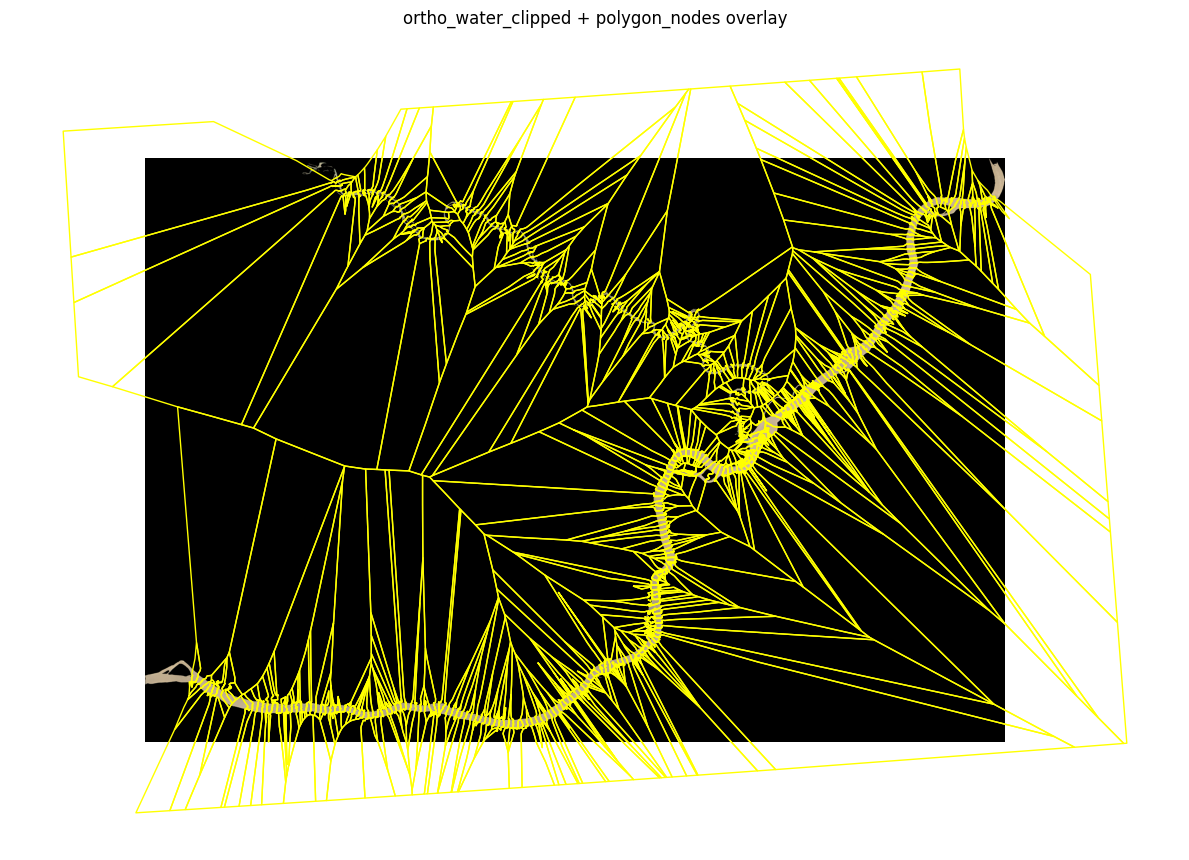

In [ ]:
# Initalize figure
fig, ax = plt.subplots(figsize=(12, 12))

# Show the RGB raster (assuming it has 3 bands: R, G, B)
# If only one band, use: show(ortho_water_clipped[0], transform=ortho_water_transform, ax=ax)
if ortho_water_clipped.shape[0] >= 3:
    show(
        ortho_water_clipped[:3],  # Use first 3 bands
        transform=ortho_water_transform,
        ax=ax
    )
else:
    show(
        ortho_water_clipped[0],
        transform=ortho_water_transform,
        ax=ax,
        cmap='gray'
    )

# Restrict to just nodes that fall within the raster bounds
raster_bounds = rasterio.transform.array_bounds(
    ortho_water_clipped.shape[1],  # height
    ortho_water_clipped.shape[2],  # width
    ortho_water_transform
)
raster_box = box(*raster_bounds)
polygon_nodes_in_bounds = polygon_nodes[polygon_nodes.intersects(raster_box)]

# Plot the node polygons
polygon_nodes_in_bounds.boundary.plot(ax=ax, edgecolor='yellow', linewidth=1)

# Clean up & title plot
ax.set_title("ortho_water_clipped + polygon_nodes overlay")
ax.set_axis_off()
plt.tight_layout()
plt.show()


## Reproject orthos

In [7]:
%%bash
gdalwarp -r bilinear -overwrite \
  -t_srs EPSG:32606 \
  /Users/camryn/Documents/UNC/_Tier1_sites/expanded_Yukon_Flats/Orthomosaics/orthos_resampled_3m/chandalar_240710_nir_ortho_3m.tif \
  /Users/camryn/Documents/UNC/_Tier1_sites/expanded_Yukon_Flats/Orthomosaics/orthos_resampled_3m/gap_filled/chandalar_240710_ortho_3m_epsg32606.tif

gdalwarp -r bilinear -overwrite \
  -t_srs EPSG:32606 \
  /Users/camryn/Documents/UNC/_Tier1_sites/expanded_Yukon_Flats/Orthomosaics/orthos_resampled_3m/coleen_240710_nir_ortho_3m.tif \
  /Users/camryn/Documents/UNC/_Tier1_sites/expanded_Yukon_Flats/Orthomosaics/orthos_resampled_3m/gap_filled/coleen_240710_ortho_3m_epsg32606.tif

gdalwarp -r bilinear -overwrite \
  -t_srs EPSG:32606 \
  /Users/camryn/Documents/UNC/_Tier1_sites/expanded_Yukon_Flats/Orthomosaics/orthos_resampled_3m/coleen_240716_nir_ortho_3m.tif \
  /Users/camryn/Documents/UNC/_Tier1_sites/expanded_Yukon_Flats/Orthomosaics/orthos_resampled_3m/gap_filled/coleen_240716_ortho_3m_epsg32606.tif

gdalwarp -r bilinear -overwrite \
  -t_srs EPSG:32606 \
  /Users/camryn/Documents/UNC/_Tier1_sites/expanded_Yukon_Flats/Orthomosaics/orthos_resampled_3m/sheenjek_240725_nir_ortho_3m.tif \
  /Users/camryn/Documents/UNC/_Tier1_sites/expanded_Yukon_Flats/Orthomosaics/orthos_resampled_3m/gap_filled/sheenjek_240725_ortho_3m_epsg32606.tif

gdalwarp -r bilinear -overwrite \
  -t_srs EPSG:32606 \
  /Users/camryn/Documents/UNC/_Tier1_sites/expanded_Yukon_Flats/Orthomosaics/orthos_resampled_3m/yukonDS_240716_nir_ortho_3m.tif \
  /Users/camryn/Documents/UNC/_Tier1_sites/expanded_Yukon_Flats/Orthomosaics/orthos_resampled_3m/gap_filled/yukonDS_240716_ortho_3m_epsg32606.tif

gdalwarp -r bilinear -overwrite \
  -t_srs EPSG:32606 \
  /Users/camryn/Documents/UNC/_Tier1_sites/expanded_Yukon_Flats/Orthomosaics/orthos_resampled_3m/yukonUS_240710_nir_ortho_3m.tif \
  /Users/camryn/Documents/UNC/_Tier1_sites/expanded_Yukon_Flats/Orthomosaics/orthos_resampled_3m/gap_filled/yukonUS_240710_ortho_3m_epsg32606.tif

Using band 4 of source image as alpha.
Creating output file that is 5716P x 9611L.
Processing /Users/camryn/Documents/UNC/_Tier1_sites/expanded_Yukon_Flats/Orthomosaics/orthos_resampled_3m/chandalar_240710_nir_ortho_3m.tif [1/1] : 0...10...20...30...40...50...60...70...80...90...100 - done.
Using band 4 of source image as alpha.
Creating output file that is 12285P x 8586L.
Processing /Users/camryn/Documents/UNC/_Tier1_sites/expanded_Yukon_Flats/Orthomosaics/orthos_resampled_3m/coleen_240710_nir_ortho_3m.tif [1/1] : 0...10...20...30...40...50...60...70...80...90...100 - done.
Using band 4 of source image as alpha.
Creating output file that is 12017P x 8723L.
Processing /Users/camryn/Documents/UNC/_Tier1_sites/expanded_Yukon_Flats/Orthomosaics/orthos_resampled_3m/coleen_240716_nir_ortho_3m.tif [1/1] : 0...10...20...30...40...50...60...70...80...90...100 - done.
Using band 4 of source image as alpha.
Creating output file that is 11858P x 9538L.
Processing /Users/camryn/Documents/UNC/_Tier